In [ ]:
#                                   REGRESSION MODEL

In [148]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,accuracy_score,mean_absolute_error,mean_squared_error
from sklearn.preprocessing import StandardScaler,LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [124]:
df=pd.read_csv(r'C:\Users\amank\Downloads\DEEP LEARNING ANN\cardekho.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [125]:
df.drop(columns=['name','max_power'],inplace=True)

In [126]:
df.rename(columns={'mileage(km/ltr/kg)':'mileage'},inplace=True)

In [ ]:
#                    FILL NULL VALUES

In [129]:
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
seats            0
dtype: int64

In [128]:
df['mileage']=df['mileage'].fillna(23)
df['engine']=df['engine'].fillna(33)
df['seats']=df['seats'].fillna(43)

In [133]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,seats,encoded_fuel,encoded_seller_type,encoded_owner,encoded_transmission
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,5.0,1,1,0,1
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,5.0,1,1,2,1
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,5.0,3,1,4,1
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,5.0,1,1,0,1
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,5.0,3,1,0,1


In [ ]:
#                         ENCODE CATEGORICAL COLUMNS

In [130]:
label=LabelEncoder()

In [132]:
df['encoded_fuel']=label.fit_transform(df['fuel'])
df['encoded_seller_type']=label.fit_transform(df['seller_type'])
df['encoded_owner']=label.fit_transform(df['owner'])
df['encoded_transmission']=label.fit_transform(df['transmission'])

In [134]:

df.drop(columns=['fuel','seller_type','owner','transmission'],inplace=True)

In [135]:
df.head()

,year,selling_price,km_driven,mileage,engine,seats,encoded_fuel,encoded_seller_type,encoded_owner,encoded_transmission
0,2014,450000,145500,23.40,1248.0,5.0,1,1,0,1
1,2014,370000,120000,21.14,1498.0,5.0,1,1,2,1
2,2006,158000,140000,17.70,1497.0,5.0,3,1,4,1
3,2010,225000,127000,23.00,1396.0,5.0,1,1,0,1
4,2007,130000,120000,16.10,1298.0,5.0,3,1,0,1


In [ ]:
#                         FEATURE SELECTION 

In [142]:
x=df.drop(columns=['selling_price'])
y=df['selling_price']

In [143]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#                       MODEL SELECTION 

In [136]:
model=Sequential()

In [156]:
model.add(Dense(523,activation='relu',input_dim=(9)))
#model.add(BatchNormalization())
#model.add(Dropout=0.1)

model.add(Dense(323,activation='relu'))
#model.add(BatchNormalization())
#model.add(Dropout=0.1)

model.add(Dense(123,activation='relu'))
#model.add(BatchNormalization())
#model.add(Dropout=0.1)

model.add(Dense(23,activation='linear'))

c:\Users\amank\Downloads\DEEP LEARNING ANN\.Deelearn\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#                COMPILE AND FIT THE MODEL 

In [157]:
history=model.compile(optimizer='adam',loss='mean_squared_error',metrics=['r2_score'])

In [158]:
history=model.fit(x_train,y_train,epochs=50,verbose=1,validation_split=0.1,batch_size=32)

Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - loss: 306929467392.0000 - r2_score: 0.5314 - val_loss: 242908495872.0000 - val_r2_score: 0.5882
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 256786890752.0000 - r2_score: 0.6079 - val_loss: 721179901952.0000 - val_r2_score: -0.2227
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 247460855808.0000 - r2_score: 0.6222 - val_loss: 231446740992.0000 - val_r2_score: 0.6076
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 247769268224.0000 - r2_score: 0.6217 - val_loss: 282886242304.0000 - val_r2_score: 0.5204
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 244206223360.0000 - r2_score: 0.6272 - val_loss: 1442869280768.0000 - val_r2_score: -1.4464
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 223649677312.0000 - r2_score: 0.6585 - val_loss: 1117298229248.0000 - val_r2_score: -0.8944
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 247931863040.0000 - r2_sco

In [ ]:
#                   PLOT INTO A GRAPH 

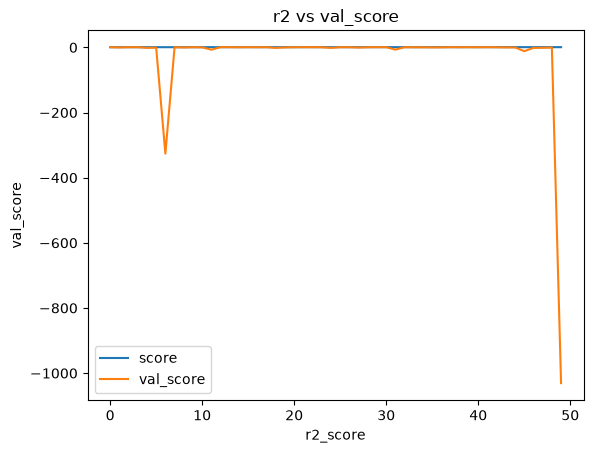

In [159]:
plt.plot(history.history['r2_score'],label='score')
plt.plot(history.history['val_r2_score'],label='val_score')
plt.title('r2 vs val_score')
plt.xlabel('r2_score')
plt.ylabel('val_score')
plt.legend()
plt.show()